In [2]:
%pip install pandas
%pip install numpy
%pip install matplotlib
%pip install seaborn
%pip install scikit-learn
%pip install xgboost
%pip install tensorflow

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 26.1.2 -> 26.2
[notice] To update, run: python.exe -m pip install --upgrade pip


Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 26.1.2 -> 26.2
[notice] To update, run: python.exe -m pip install --upgrade pip


Note: you may need to restart the kernel to use updated packages.


...


[notice] A new release of pip is available: 26.1.2 -> 26.2
[notice] To update, run: python.exe -m pip install --upgrade pip


Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 26.1.2 -> 26.2
[notice] To update, run: python.exe -m pip install --upgrade pip


Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 26.1.2 -> 26.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [3]:
# Data Manipulation
import pandas as pd
import numpy as np

# Data Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Data Preprocessing and Model Evaluation
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Machine Learning Models
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor

# Deep Learning (LSTM)
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense

LOAD AND INSPECTION OF DATA

In [4]:
df = pd.read_csv("../data/raw/data.csv")

In [5]:
print(df.shape)

(238, 9)


In [6]:
print(df.info())

<class 'pandas.DataFrame'>
RangeIndex: 238 entries, 0 to 237
Data columns (total 9 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   country     238 non-null    str    
 1   continent   236 non-null    str    
 2   population  229 non-null    float64
 3   day         238 non-null    str    
 4   time        238 non-null    str    
 5   Cases       238 non-null    int64  
 6   Recovered   190 non-null    float64
 7   Deaths      233 non-null    float64
 8   Tests       213 non-null    float64
dtypes: float64(4), int64(1), str(4)
memory usage: 16.9 KB
None


In [7]:
print(df.describe())

         population         Cases     Recovered        Deaths         Tests
count  2.290000e+02  2.380000e+02  1.900000e+02  2.330000e+02  2.130000e+02
mean   3.469404e+07  8.883449e+06  1.006214e+07  9.026621e+04  3.298829e+07
std    1.386374e+08  5.193031e+07  5.555519e+07  5.163434e+05  1.198779e+08
min    7.990000e+02  9.000000e+00  2.000000e+00  1.000000e+00  7.850000e+03
25%    4.454310e+05  2.741875e+04  2.197250e+04  2.250000e+02  3.478150e+05
50%    5.797805e+06  2.320425e+05  2.351455e+05  2.570000e+03  2.226216e+06
75%    2.210284e+07  1.565481e+06  2.078212e+06  1.805700e+04  1.346373e+07
max    1.448471e+09  7.047539e+08  6.756198e+08  7.010681e+06  1.186852e+09


In [8]:
print(df.isnull().sum())

country        0
continent      2
population     9
day            0
time           0
Cases          0
Recovered     48
Deaths         5
Tests         25
dtype: int64


DATA CLEANING

In [9]:
df['continent'] = df['continent'].fillna(df['continent'].mode()[0])

df['population'] = df['population'].fillna(df['population'].median())

df['Recovered'] = df['Recovered'].fillna(df['Recovered'].median())

df['Deaths'] = df['Deaths'].fillna(df['Deaths'].median())

df['Tests'] = df['Tests'].fillna(df['Tests'].median())

In [10]:
print(df.isnull().sum())

country       0
continent     0
population    0
day           0
time          0
Cases         0
Recovered     0
Deaths        0
Tests         0
dtype: int64


In [11]:
print(df.duplicated().sum())

0


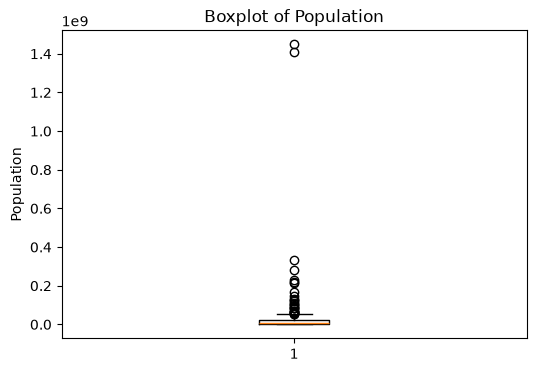

In [12]:
plt.figure(figsize=(6, 4))
plt.boxplot(df['population'])
plt.title('Boxplot of Population')
plt.ylabel('Population')
plt.show()

INTERPRETATION OF THE BOXPLOT OF POPULATION 

The boxplot above shows the distribution of the Population variable and helps identify any potential outliers.
The vertical axis (y-axis) is labelled Population, indicating that the graph represents the population of each country in the dataset.
At the top left of the graph, the notation 1e9 is displayed. This is scientific notation, which means 1 × 10⁹ = 1,000,000,000 (1 billion). Matplotlib uses scientific notation because the population values are very large. Therefore, each number on the y-axis should be multiplied by 1 billion. For example:
0.2 = 200,000,000 (200 million)
0.4 = 400,000,000 (400 million)
1.0 = 1,000,000,000 (1 billion)
1.4 = 1,400,000,000 (1.4 billion)
The orange horizontal line inside the box represents the median population. The median is the middle value when all countries are arranged from the smallest population to the largest. This means that approximately 50% of the countries have populations below the median, while the other 50% have populations above the median.
The rectangular box represents the middle 50% of the population values, also known as the interquartile range (IQR). Most countries in the dataset have populations within this week range.
The whiskers (the thin vertical lines extending from the box) indicate the range of population values that are considered normal according to the boxplot. Any values beyond these whiskers are identified as potential outliers.
The black circles above the whiskers represent potential outliers. Each circle corresponds to a country whose population is significantly larger than that of most other countries. Examples include countries such as India and China, whose populations exceed one billion people. These countries appear far above the rest because their populations are much higher than the majority of countries in the dataset.

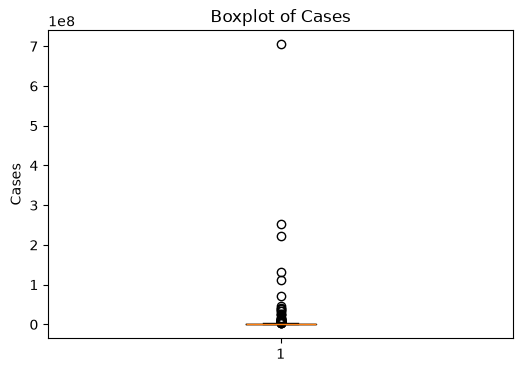

In [13]:
plt.figure(figsize=(6, 4))
plt.boxplot(df['Cases'])
plt.title('Boxplot of Cases')
plt.ylabel('Cases')
plt.show()

INTERPRETATION OF THE BOXPLOT OF CASES

The boxplot was used to examine the distribution of the COVID-19 cases and identify potential outliers in the dataset. The notation 1e8 shown at the top of the graph is scientific notation, which means �, or 100,000,000 (100 million). Matplotlib uses this notation to simplify the display of very large numbers. Therefore, the values on the y-axis are multiplied by 100,000,000. For example, 1 represents 100,000,000 cases, 2 represents 200,000,000 cases, and 7 represents 700,000,000 cases. The orange horizontal line inside the box represents the median, which is the middle value of the COVID-19 cases after arranging the data from the smallest to the largest. This means that 50% of the observations lie below the median and 50% lie above it. The box represents the middle 50% of the data, but in this graph it appears almost invisible because a few countries have exceptionally high numbers of COVID-19 cases. These extreme values stretch the scale of the graph, causing the box to be compressed near the bottom. The whiskers represent the range of values considered to be within the normal spread of the data, while the black circles above the whiskers represent potential outliers. In this dataset, these outliers correspond to countries with exceptionally high COVID-19 case counts. Since these values are genuine observations and not data entry errors, they were retained because they contain important information for predicting disease spread and improve the reliability of the prediction models.

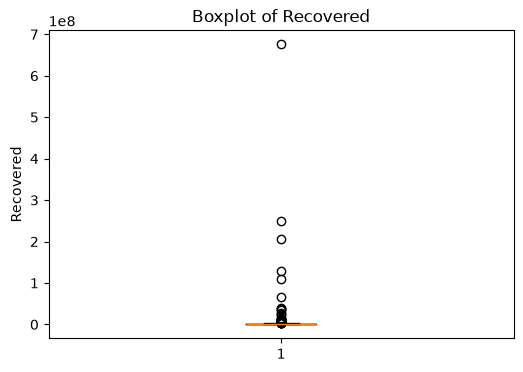

In [14]:
plt.figure(figsize=(6, 4))
plt.boxplot(df['Recovered'])
plt.title('Boxplot of Recovered')
plt.ylabel('Recovered')
plt.show()

INTERPRETATION OF THE BOXPLOTS 

The boxplot of the Recovered variable was used to examine the distribution of COVID-19 recovery cases and identify potential outliers. The notation 1e8 at the top left is scientific notation, meaning the values on the y-axis are expressed in hundreds of millions (1 × 10⁸ = 100,000,000). Therefore, a value of 1 on the y-axis represents 100 million recoveries, while 2 represents 200 million recoveries. The orange horizontal line represents the median (middle) number of recoveries, indicating that approximately 50% of the countries have recovery counts below the median and 50% have recovery counts above it. The box represents the middle 50% of the recovery values, while the whiskers indicate the normal range of the data. The black circles above the whiskers represent countries with exceptionally high recovery counts, which are identified as potential outliers. These outliers were retained because they are genuine observations from countries with high numbers of COVID-19 recoveries and not data entry errors, making them important for accurately predicting disease spread.

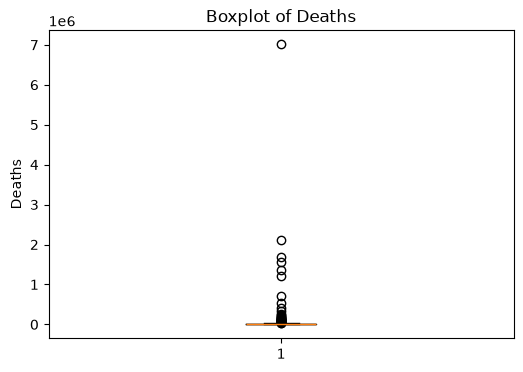

In [15]:
plt.figure(figsize=(6, 4))
plt.boxplot(df['Deaths'])
plt.title('Boxplot of Deaths')
plt.ylabel('Deaths')
plt.show()

INTERPRETATION OF THE BOXPLOT OF DEATHS

The boxplot of the Deaths variable was used to examine the distribution of COVID-19 death cases and identify potential outliers. The notation 1e6 at the top left is scientific notation, meaning the values on the y-axis are expressed in millions (1 × 10⁶ = 1,000,000). Therefore, a value of 1 on the y-axis represents 1 million deaths, 2 represents 2 million deaths, and 7 represents 7 million deaths. The orange horizontal line represents the median (middle) number of deaths, indicating that approximately 50% of the countries have death counts below the median and 50% have death counts above it. The box represents the middle 50% of the death values, while the whiskers indicate the normal range of the data. The black circles above the whiskers represent countries with exceptionally high COVID-19 death counts, which are identified as potential outliers. These outliers were retained because they are genuine observations from countries with significantly higher death counts rather than data entry errors, making them important for accurately predicting disease spread.

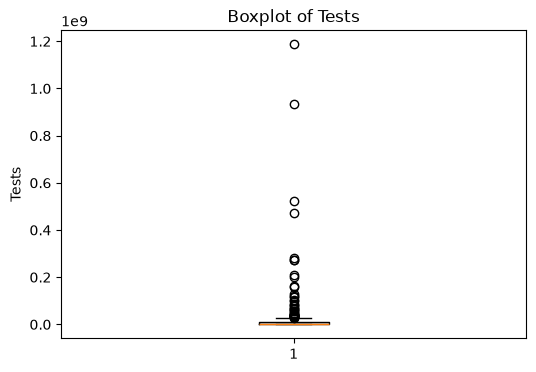

In [16]:
plt.figure(figsize=(6, 4))
plt.boxplot(df['Tests'])
plt.title('Boxplot of Tests')
plt.ylabel('Tests')
plt.show()

INTERPRETAION OF THE BOXPLOTS OF TESTS

The boxplot of the Tests variable was used to examine the distribution of COVID-19 testing data and identify potential outliers. The notation at the top left of the graph (such as 1e8) is scientific notation, meaning the values on the y-axis are expressed in hundreds of millions (1 × 10⁸ = 100,000,000). Therefore, a value of 1 on the y-axis represents 100 million tests, while 2 represents 200 million tests. The orange horizontal line represents the median (middle) number of tests, indicating that approximately 50% of the countries have testing counts below the median and 50% have testing counts above it. The box represents the middle 50% of the testing values, while the whiskers indicate the normal range of the data. The black circles above the whiskers represent countries with exceptionally high numbers of COVID-19 tests, which are identified as potential outliers. These outliers were retained because they are genuine observations from countries that conducted significantly more COVID-19 tests rather than data entry errors, making them important for accurately predicting disease spread.

EXPLORATORY DATA ANALYSIS (EDA)

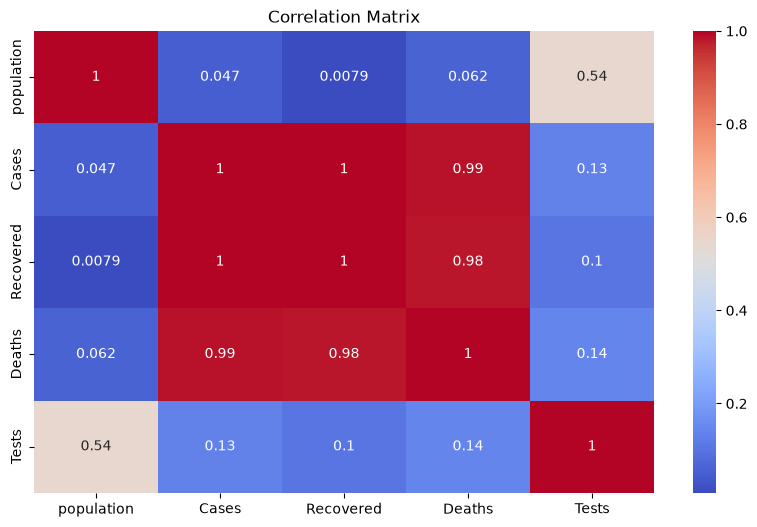

In [17]:
plt.figure(figsize=(10, 6))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm')
plt.title('Correlation Matrix')
plt.show()

INTERPRETATION

The correlation matrix shows the relationship between the five numerical variables (Population, Cases, Recovered, Deaths, and Tests) in the COVID-19 dataset. Cases, Recovered, and Deaths have very strong positive correlations (0.98–1.00), indicating that these variables increase together. Population has a moderate positive correlation with Tests (0.54), suggesting that countries with larger populations generally conduct more COVID-19 tests. However, Population has very weak correlations with Cases (0.047), Recovered (0.0079), and Deaths (0.062), indicating little relationship with these variables. Overall, the heatmap suggests that COVID-19 cases, recoveries, and deaths are closely related, while population size has a weaker influence on disease outcomes in this dataset.

The vertical color line is the legend (key) of the heatmap. It shows what each color represents. In your heatmap, values closer to 0 (such as 0.0079, 0.10, and 0.14) appear light blue because they indicate very weak positive correlations, while values closer to 1 (such as 0.98, 0.99, and 1.00) appear dark red because they indicate very strong positive correlations. Therefore, the color of each box is determined by its correlation value according to the vertical color scale.

FEATURE ENGINEERING

In [18]:
print(df.columns)

Index(['country', 'continent', 'population', 'day', 'time', 'Cases',
       'Recovered', 'Deaths', 'Tests'],
      dtype='str')


In [19]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

df['country'] = le.fit_transform(df['country'])
df['continent'] = le.fit_transform(df['continent'])

This code converts the categorical text values in the country and continent columns into numerical labels using LabelEncoder, making them suitable for use by our machine-learning models.

print(df.columns) displays the names of all the columns currently present in the DataFrame df, so i can check which variables are available before continuing with data processing and feature engineering. Because i use print(df.columns) to check what columns are actually inside df before writing the next code.
In our case, it helped us discover that day was no longer there, while year, month, and day_of_month were present. This prevented us from writing code that refers to a column that doesn't exist.

In [28]:
X = df.drop('Cases', axis=1)
y = df['Cases']

X = X.drop(columns=['time', 'day'], errors='ignore')

Explanation: This code separates our dataset into features (X), which contain the information the models will use to make predictions, and the target (y), which is Cases, the value we want to predict; it also removes time and day because they contain text/date information that cannot be directly processed by StandardScaler.

In [29]:
print(X.dtypes)
print(X.columns)

country         int64
continent       int64
population    float64
Recovered     float64
Deaths        float64
Tests         float64
dtype: object
Index(['country', 'continent', 'population', 'Recovered', 'Deaths', 'Tests'], dtype='str')


Explanation: This code checks the data type of every feature and displays the feature names so that we can confirm that the variables going into the scaling process are numerical and that no unwanted text/date column remains.

In [30]:
from sklearn.model_selection import train_test_split

# Split the data into training and testing sets

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("Training data shape:", X_train.shape)
print("Testing data shape:", X_test.shape)

Training data shape: (190, 6)
Testing data shape: (48, 6)


Explanation: This cell divides our prepared data into training data and testing data. The test_size=0.2 means that 80% of the data is used for training and 20% is reserved for testing. random_state=42 ensures that we get the same division each time we run the code.
Why: The models need one portion of the data to learn patterns and another portion they have not seen to test how well they can make predictions.

In [31]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Feature scaling completed successfully.")
print("Scaled training data shape:", X_train_scaled.shape)
print("Scaled testing data shape:", X_test_scaled.shape)

Feature scaling completed successfully.
Scaled training data shape: (190, 6)
Scaled testing data shape: (48, 6)


Explanation: This code uses StandardScaler to put the numerical features on a comparable scale; fit_transform() learns the scaling from the training data and scales it, while transform() applies exactly the same scaling to the testing data, which prevents information from the test set from influencing the training process.

In [32]:
from sklearn.model_selection import train_test_split

# Split the data into training and testing sets

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("Training data shape:", X_train.shape)
print("Testing data shape:", X_test.shape)

Training data shape: (190, 6)
Testing data shape: (48, 6)


Explanation: This cell divides our data into 80% training data and 20% testing data. The training data will be used by the LSTM, Random Forest Regressor, and XGBoost Regressor to learn patterns, while the testing data will be kept separate so we can later evaluate how well each model predicts unseen Cases data. Because We need separate training and testing data so that our model evaluation is fair and we can see whether the models can generalize to data they did not train on. The Training data shape: (190, 9) means 190 rows and 9 features will be used to train the models while Testing data shape: (48, 9) means 48 rows and the same 9 features will be used to test the models.

In [33]:
from sklearn.preprocessing import StandardScaler

# Scale the features
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Feature scaling completed successfully.")
print("Scaled training data shape:", X_train_scaled.shape)
print("Scaled testing data shape:", X_test_scaled.shape)

Feature scaling completed successfully.
Scaled training data shape: (190, 6)
Scaled testing data shape: (48, 6)


Explanation: This cell standardizes the 9 features so they are on a comparable scale. The scaler learns the required scaling only from the training data and then applies that same scaling to both the training and testing data.
Why: Our variables have very different ranges for example, population and cases can be very large, while month and day are much smaller. Scaling makes the data more suitable for our machine-learning models. My Feature Engineering is now completed successfully. Training data: (190, 9), Testing data: (48, 9) What this means is that dataset is now prepared for my three selected models which are as follows:
LSTM
Random Forest Regressor
XGBoost Regressor

SETING UP LSTM

In [34]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense
import numpy as np

# Reshape the data for LSTM
X_train_lstm = np.reshape(
    X_train_scaled,
    (X_train_scaled.shape[0], 1, X_train_scaled.shape[1])
)

X_test_lstm = np.reshape(
    X_test_scaled,
    (X_test_scaled.shape[0], 1, X_test_scaled.shape[1])
)

print("LSTM data shape:", X_train_lstm.shape)

LSTM data shape: (190, 1, 6)


Explanation: This cell imports the LSTM tools and reshapes our scaled training and testing data into the 3-dimensional format required by an LSTM, which is (samples, time steps, features).
Why: Unlike Random Forest and XGBoost, an LSTM expects data in a sequence format. We have 190 training samples, 1 time step, and 9 features, so the expected training shape should be (190, 1, 9).The LSTM data shape: (190,1,9) it means that 190 = training samples, 1 = time step, 9 = input features

BUILDING THE LSTM MODEL

In [40]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, LSTM, Dense

# Create the LSTM model
model_lstm = Sequential([
    Input(shape=(1, 6)),
    LSTM(50),
    Dense(1)
])

# Compile the model
model_lstm.compile(
    optimizer="adam",
    loss="mse"
)

print("LSTM model created successfully.")

LSTM model created successfully.


Explanation: This code checks the data type of every feature and displays the feature names so that we can confirm that the variables going into the scaling process are numerical and that no unwanted text/date column remains.

In [39]:
print("X_train_scaled shape:", X_train_scaled.shape)
print("X_test_scaled shape:", X_test_scaled.shape)
print("X_train_lstm shape:", X_train_lstm.shape)
print("X_test_lstm shape:", X_test_lstm.shape)
print("y_train shape:", y_train.shape)

X_train_scaled shape: (190, 6)
X_test_scaled shape: (48, 6)
X_train_lstm shape: (190, 1, 6)
X_test_lstm shape: (48, 1, 6)
y_train shape: (190,)


TRAINING THE LSTM MODEL

In [41]:
history_lstm = model_lstm.fit(
    X_train_lstm,
    y_train,
    epochs=50,
    batch_size=16,
    validation_split=0.2,
    verbose=1
)

Epoch 1/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 6s 100ms/step - loss: 3675630327562240.0000 - val_loss: 1736822497476608.0000
Epoch 2/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - loss: 3675629790691328.0000 - val_loss: 1736822497476608.0000
Epoch 3/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step - loss: 3675629790691328.0000 - val_loss: 1736822497476608.0000
Epoch 4/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - loss: 3675630059126784.0000 - val_loss: 1736822497476608.0000
Epoch 5/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - loss: 3675630059126784.0000 - val_loss: 1736822497476608.0000
Epoch 6/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - loss: 3675630595997696.0000 - val_loss: 1736822497476608.0000
Epoch 7/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - loss: 3675630327562240.0000 - val_loss: 1736822497476608.0000
Epoch 8/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - loss: 3675629790691328.0000 - val_loss: 1736822497476608.0000
Epoch 9/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - loss: 3675629790691328.000

Explanation: This cell trains the LSTM using the training data. epochs=50 means the model goes through the training data up to 50 times, batch_size=16 means it processes 16 samples at a time, and validation_split=0.2 reserves 20% of the training data to monitor the model's performance during training.
Why: This is where the LSTM actually learns patterns from our disease-spread data. Epoch 1/50 means the LSTM started its first training cycle out of 50.
Epoch 50/50 means it completed all 50 training cycles.
10/10 means that each epoch was divided into 10 batches/steps for processing the training data.
Since it reached Epoch 50/50 without an error, the LSTM has finished training successfully.

MAKING PREDICTION FROM LSTM

In [42]:
lstm_predictions = model_lstm.predict(X_test_lstm)

lstm_predictions = lstm_predictions.flatten()

print("LSTM predictions completed.")
print("Number of predictions:", len(lstm_predictions))

2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 516ms/step
LSTM predictions completed.
Number of predictions: 48


Explanation: This cell uses the LSTM that we have just trained to predict the number of Cases for our test data. The flatten() converts the predictions into a simple one-dimensional format so that we can easily compare them with the actual y_test values.

LSTM EVALUATION

In [48]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

lstm_mae = mean_absolute_error(y_test, lstm_predictions)
lstm_mse = mean_squared_error(y_test, lstm_predictions)
lstm_rmse = np.sqrt(lstm_mse)
lstm_r2 = r2_score(y_test, lstm_predictions)

print("LSTM Results")
print("MAE:", lstm_mae)
print("MSE:", lstm_mse)
print("RMSE:", lstm_rmse)
print("R2 Score:", lstm_r2)

LSTM Results
MAE: 7695541.5
MSE: 692047342206976.0
RMSE: 26306792.70087815
R2 Score: -0.09358227252960205


SETTINGUP RANDOM FOREST

In [44]:
from sklearn.ensemble import RandomForestRegressor

# Set up the Random Forest Regression model
rf_model = RandomForestRegressor(
    n_estimators=200,
    random_state=42
)

print("Random Forest model set up successfully.")

Random Forest model set up successfully.


This cell imports Random Forest Regression and creates the Random Forest model with 200 decision trees, preparing it to learn patterns from our disease-spread data.

RAINING THE RANDOM FOREST MODEL

In [45]:
# Train the Random Forest model
rf_model.fit(X_train, y_train)

print("Random Forest model trained successfully.")

Random Forest model trained successfully.


Explanation in one statement: This cell trains the Random Forest model using the training features (X_train) and the actual Cases values (y_train), allowing the model to learn patterns that it will use to predict disease spread.

MAKING RANDOM FOREST PREDICTIONS

In [46]:
# Make predictions using the Random Forest model
rf_predictions = rf_model.predict(X_test)

print("Random Forest predictions completed.")
print("Number of predictions:", len(rf_predictions))

Random Forest predictions completed.
Number of predictions: 48


Explanation in one statement: This cell uses the trained Random Forest model to predict the number of Cases for the 48 test samples that the model did not use during training.

RANDOM FOREST EVALUATION

In [47]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

rf_mae = mean_absolute_error(y_test, rf_predictions)
rf_mse = mean_squared_error(y_test, rf_predictions)
rf_rmse = np.sqrt(rf_mse)
rf_r2 = r2_score(y_test, rf_predictions)

print("Random Forest Results")
print("MAE:", rf_mae)
print("MSE:", rf_mse)
print("RMSE:", rf_rmse)
print("R2 Score:", rf_r2)

Random Forest Results
MAE: 1919135.5168750004
MSE: 45652036135395.8
RMSE: 6756629.051190822
R2 Score: 0.9278600548408411


SETTINGUP XGBOOST

In [49]:
from xgboost import XGBRegressor

# Set up the XGBoost Regression model
xgb_model = XGBRegressor(
    n_estimators=200,
    random_state=42,
    objective="reg:squarederror"
)

print("XGBoost model set up successfully.")

XGBoost model set up successfully.


Explanation: This cell imports and creates the XGBoost Regression model, using 200 boosting trees and a squared-error objective because our task is to predict the numerical Cases value.

TRAINING THE XGBOOST

In [50]:
# Train the XGBoost model
xgb_model.fit(X_train, y_train)

print("XGBoost model trained successfully.")

XGBoost model trained successfully.


Explanation: This cell trains the XGBoost Regression model using X_train and y_train, allowing it to learn patterns in the training data that can be used to predict future disease cases.

MAKING PREDICTIONS

In [51]:
# Make predictions using the XGBoost model
xgb_predictions = xgb_model.predict(X_test)

print("XGBoost predictions completed.")
print("Number of predictions:", len(xgb_predictions))

XGBoost predictions completed.
Number of predictions: 48


Explanation: This cell uses the trained XGBoost model to predict the number of Cases for the 48 test samples that were kept separate from the training data.

XGBOOST EVALUATIONS

In [52]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

xgb_mae = mean_absolute_error(y_test, xgb_predictions)
xgb_mse = mean_squared_error(y_test, xgb_predictions)
xgb_rmse = np.sqrt(xgb_mse)
xgb_r2 = r2_score(y_test, xgb_predictions)

print("XGBoost Results")
print("MAE:", xgb_mae)
print("MSE:", xgb_mse)
print("RMSE:", xgb_rmse)
print("R2 Score:", xgb_r2)

XGBoost Results
MAE: 2717804.75
MSE: 116784623517696.0
RMSE: 10806693.459041761
R2 Score: 0.815455436706543


Explanation: This cell evaluates the XGBoost model by comparing its predicted Cases values with the actual test values using MAE, MSE, RMSE, and R² Score, allowing us to determine how well XGBoost performed.

## MODEL COMPARISON AND JUSTIFICATION

This section compares the performance of the three machine-learning models used for predicting disease spread: LSTM, Random Forest, and XGBoost.

The models are compared using Mean Absolute Error (MAE), Root Mean Squared Error (RMSE), and R² Score. Lower MAE and RMSE values indicate smaller prediction errors, while a higher R² Score indicates better predictive performance.

In [53]:
import pandas as pd

comparison = pd.DataFrame({
    "Model": ["LSTM", "Random Forest", "XGBoost"],
    "MAE": [lstm_mae, rf_mae, xgb_mae],
    "RMSE": [lstm_rmse, rf_rmse, xgb_rmse],
    "R2 Score": [lstm_r2, rf_r2, xgb_r2]
})

print("MODEL COMPARISON")
display(comparison)

MODEL COMPARISON


,Model,MAE,RMSE,R2 Score
0,LSTM,7.695542e+06,2.630679e+07,-0.093582
1,Random Forest,1.919136e+06,6.756629e+06,0.927860
2,XGBoost,2.717805e+06,1.080669e+07,0.815455


## JUSTIFICATION FOR MODEL SELECTION

Based on the evaluation results, Random Forest was selected as the best-performing model for predicting disease spread.

Random Forest achieved the highest R² Score of approximately 0.928, indicating that it explains a large proportion of the variation in the target variable (Cases). It also achieved the lowest MAE and RMSE among the three models, meaning that its predictions had the smallest errors.

XGBoost performed well with an R² Score of approximately 0.815, but its errors were higher than those of Random Forest. LSTM performed poorly on this dataset, with a negative R² Score of approximately -0.094.

Therefore, Random Forest was selected as the final model because it provided the best overall predictive performance based on R² Score, MAE, and RMSE.

SAVING THE SELECTED RANDOM FOREST MODEL

In [54]:
import joblib

# Save the selected Random Forest model
joblib.dump(rf_model, "../models/trained_model.pkl")

print("Random Forest model saved successfully.")

Random Forest model saved successfully.


This cell saves the trained Random Forest model to the models folder using joblib, so that the model can be loaded and reused later for making predictions without training it again.

In [55]:
import joblib

# Load the saved Random Forest model
loaded_model = joblib.load("../models/trained_model.pkl")

print("Saved Random Forest model loaded successfully.")

Saved Random Forest model loaded successfully.


This confirms that the model was saved correctly and can be reused later by our prediction system/backend.

In [56]:
import joblib

# Save the feature column order
feature_columns = X_train.columns.tolist()

joblib.dump(feature_columns, "../models/feature_columns.pkl")

print("Feature columns saved successfully.")

Feature columns saved successfully.


Explanation: This cell saves the exact names and order of the features used to train our Random Forest model, so that when we later receive new data through the prediction system, the input can be arranged in exactly the same order as the training data.